# Supermarket Sales Analysis ##

### Objective:
The objectives for data analysis in your supermarket sales project should focus on understanding patterns, trends, and opportunities to support data-driven decision-making.


### Problem Statement: 
Supermarket often struggle to optimize product placement, forecast demand, and identify high-performing products. This project aims to analyze the supermarket sales data.
Identify the most and least popular products.
Understand seasonal trends and peak sales periods.
Determine the relationship between sales and customer demographics.
Suggest ways to optimize inventory and marketing strategies.


What is the total sales and total profit?
What is the average sales & profit per order?
Which product category generates the most sales and which generates the most profit?
Which product sub-category has the highest average sales & profit?
Which customer segment (Consumer, Corporate, Home Office) generates the most sales & profit?
Which state generates the most sales & Profit?
Which city generates the most sales & profit?
What is the total sales & profit by each ship mode?
What is the total sales & profit by each product?
What is the total sales & profit by each region?
What are the total sales and profit over time year?
How does the sales trend look over the months/years?
Which months have the highest sales in 2014, 2015, 2016, 2017?
What is the total sales and profit by customer (Customer ID or Customer Name)?
Which customers have made the highest number of orders?
How many products in each sub-category are sold in total (Quantity)?

## Install & Import Necessary Libraries ##

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Loading Dataset ##

In [16]:
# download from https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
# Load the CSV file into a pandas DataFrame
# Path to your Excel file
file_path = 'D:/Anudip/Python/Project/Book2.xlsx'
df = pd.read_excel(file_path)

In [18]:
# Display the first 5 rows of the DataFrame
df.head(6)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Total Sales
0,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136,523.920
1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.0,219.5820,2195.820
2,CA-2016-161389,2016-05-12,2016-10-12,Standard Class,IM-15070,Irene Maddox,Consumer,Seattle,Washington,98103,West,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.976,3,0.2,132.5922,1223.728
3,CA-2016-117590,2016-08-12,2016-10-12,First Class,GH-14485,Gene Hale,Corporate,Richardson,Texas,75080,Central,TEC-PH-10004977,Technology,Phones,GE 30524EE4,1097.544,7,0.2,123.4737,7682.608
4,CA-2016-117590,2016-08-12,2016-10-12,First Class,GH-14485,Gene Hale,Corporate,Richardson,Texas,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.920,5,0.6,-147.9630,954.000
5,CA-2014-106376,2014-05-12,2014-10-12,Standard Class,BS-11590,Brendan Sweed,Corporate,Gilbert,Arizona,85234,West,OFF-AR-10002671,Office Supplies,Art,Hunt BOSTON Model 1606 High-Volume Electric Pe...,1113.024,8,0.2,111.3024,8903.992


## Understand the Structure of the Data ##

In [8]:
# Checking overview of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2739 entries, 0 to 2738
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       2739 non-null   object        
 1   Order Date     2739 non-null   datetime64[ns]
 2   Ship Date      2739 non-null   datetime64[ns]
 3   Ship Mode      2739 non-null   object        
 4   Customer ID    2739 non-null   object        
 5   Customer Name  2739 non-null   object        
 6   Segment        2739 non-null   object        
 7   City           2739 non-null   object        
 8   State          2739 non-null   object        
 9   Postal Code    2739 non-null   int64         
 10  Region         2739 non-null   object        
 11  Product ID     2739 non-null   object        
 12  Category       2739 non-null   object        
 13  Sub-Category   2739 non-null   object        
 14  Product Name   2739 non-null   object        
 15  Sales          2739 n

In [9]:
# Used to generate descriptive statistics for the numerical columns in a DataFrame
# Quick summary of key statistical measures such as count, mean, standard deviation, minimum, and maximum values, as well as quartiles (25th, 50th, and 75th percentiles).
df.describe()

,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Total Sales
count,2739,2739,2739.000000,2739.000000,2739.000000,2739.000000,2739.000000,2739.000000
mean,2016-02-05 17:53:33.581598976,2016-05-22 15:33:42.782037248,54220.505294,230.971407,3.767798,0.158759,31.325717,1122.454815
min,2014-01-02 00:00:00,2014-02-05 00:00:00,1040.000000,0.556000,1.000000,0.000000,-3839.990400,-0.244000
25%,2015-03-11 00:00:00,2015-07-12 00:00:00,22178.500000,17.902000,2.000000,0.000000,1.828050,51.897000
50%,2016-04-07 00:00:00,2016-07-12 00:00:00,53142.000000,58.240000,3.000000,0.200000,8.773500,189.800000
75%,2017-02-12 00:00:00,2017-06-11 00:00:00,90004.000000,200.387500,5.000000,0.200000,30.599900,730.875000
max,2017-12-11 00:00:00,2017-12-12 00:00:00,99207.000000,17499.950000,14.000000,0.800000,8399.976000,87499.750000
std,NaN,NaN,32183.801502,629.384413,2.205670,0.206339,244.168288,3662.541871


In [10]:
# Checking rows & columns present in data frame
df.shape

(2739, 20)

In [11]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Total Sales'],
      dtype='object')

## Data Cleaning ##

In [19]:
# Found DataFrame with datetime columns, Convert columns from datetime to date

In [13]:
# Convert columns from datetime to date (removes the time part)
df['Order Date'] = df['Order Date'].dt.date

In [15]:
df['Ship Date'] = df['Ship Date'].dt.date

In [19]:
# Check the DataFrame and column data types
print(df)
print(df.dtypes)

            Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0     CA-2016-152156  2016-08-11  2016-11-11    Second Class    CG-12520   
1     CA-2016-152156  2016-08-11  2016-11-11    Second Class    CG-12520   
2     CA-2016-161389  2016-05-12  2016-10-12  Standard Class    IM-15070   
3     CA-2016-117590  2016-08-12  2016-10-12     First Class    GH-14485   
4     CA-2016-117590  2016-08-12  2016-10-12     First Class    GH-14485   
...              ...         ...         ...             ...         ...   
2734  US-2016-103674  2016-06-12  2016-10-12  Standard Class    AP-10720   
2735  US-2016-103674  2016-06-12  2016-10-12  Standard Class    AP-10720   
2736  US-2015-151435  2015-06-09  2015-09-09    Second Class    SW-20455   
2737  CA-2017-163566  2017-03-08  2017-06-08     First Class    TB-21055   
2738  CA-2017-119914  2017-04-05  2017-09-05    Second Class    CC-12220   

        Customer Name      Segment         City       State  Postal Code  \
0         C

In [25]:
# Important part of data analysis, check duplicates
# Using Conditional statement
if df.duplicated().sum() > 0:
    print('Duplicates are present in dataframe')
else:
    print('Duplicate does not exist')

Duplicate does not exist


In [27]:
# Another method of check dupicates
df.duplicated().sum()

0

In [29]:
# Check for null values
df.isnull().sum()

# Remove rows with null values in the column
# df.dropna(subset=['Column Name'])
# Remove duplicates based on the column
# df.drop_duplicates(subset=['Column Name'])

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Total Sales      0
dtype: int64

In [9]:
# Returns a DataFrame of boolean values: True or False
df.isna()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Total Sales
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2734,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2735,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2736,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2737,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Exploratory Data Analysis (EDA) ##

In [32]:
# What is the total sales and total profit?
df['Total Sales'].sum().round()

3074404.0

In [34]:
df['Profit'].sum().round()

85801.0

In [36]:
# Count the number of unique orders
UniqueOrders = df['Order ID'].nunique()
print(UniqueOrders)

1358


In [38]:
# Calculate the average sales per order
# AverageSalesPerOrder = Total Sales / UniqueOrders or using groupby 
AverageSalesPerOrder = df.groupby('Order ID')['Total Sales'].sum().mean().round()
print(f"Average Sales per Order: ${AverageSalesPerOrder:,.2f}")

Average Sales per Order: $2,264.00


In [223]:
# Calculate the average Profit per order
# AverageProfitPerOrder = Total Sales / UniqueOrders or using groupby 
AverageProfitPerOrder = df.groupby('Order ID')['Profit'].sum().mean().round()
print(f"Average Profit per Order: ${AverageProfitPerOrder:,.2f}")

Average Profit per Order: $63.00


In [40]:
df['Category'].value_counts()

Category
Office Supplies    1642
Furniture           577
Technology          520
Name: count, dtype: int64

In [42]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        421
Paper          380
Furnishings    261
Phones         237
Storage        234
Accessories    221
Art            212
Chairs         169
Appliances     123
Labels         107
Tables          90
Envelopes       64
Fasteners       58
Bookcases       57
Supplies        43
Machines        38
Copiers         24
Name: count, dtype: int64

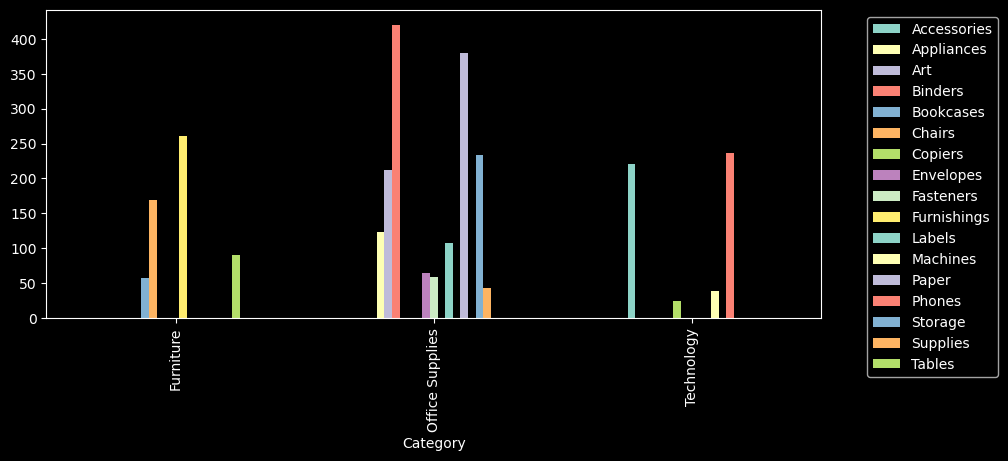

In [166]:
# distribution of products across different categories & sub-categories have higher counts of products
pd.crosstab(df['Category'], df['Sub-Category']).plot(kind='bar', stacked=False, figsize=(10, 4))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [45]:
# Identify product category generates the most sales and which generates the most profit?
CategorySalesProfit = df.groupby('Category')[['Total Sales', 'Profit']].sum().round()
print(CategorySalesProfit)

                 Total Sales   Profit
Category                             
Furniture          1040408.0   8026.0
Office Supplies     819439.0  27022.0
Technology         1214556.0  50754.0


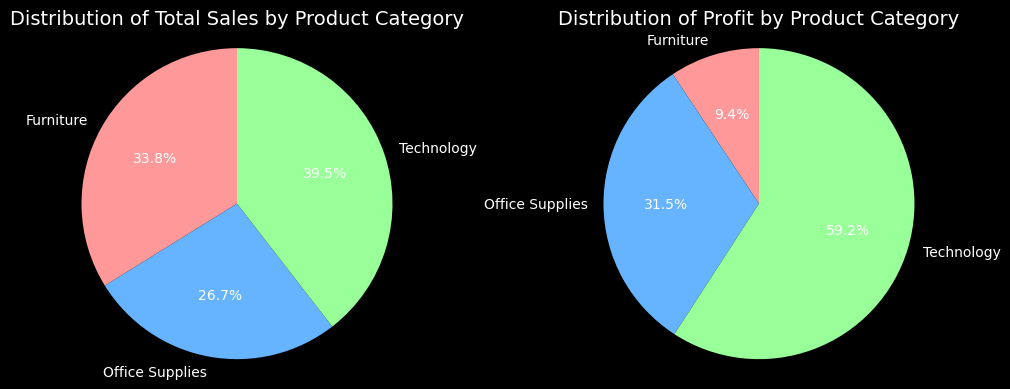

In [164]:
# Identify product category generates the most sales and which generates the most profit?
# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Pie chart for Total Sales
axes[0].pie(CategorySalesProfit['Total Sales'], 
            labels=CategorySalesProfit.index, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['#ff9999','#66b3ff','#99ff99'])
axes[0].set_title('Distribution of Total Sales by Product Category', fontsize=14)
axes[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Pie chart for Profit
axes[1].pie(CategorySalesProfit['Profit'], 
            labels=CategorySalesProfit.index, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['#ff9999','#66b3ff','#99ff99'])
axes[1].set_title('Distribution of Profit by Product Category', fontsize=14)
axes[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()

In [50]:
# Identify product sub-category has the highest average sales?
AverageSales_Subcategory = df.groupby('Sub-Category')[['Total Sales', 'Profit']].mean().round()

# Sort by Total Sales in descending order to find the highest average sales
AverageSales_Subcategory_sorted = AverageSales_Subcategory.sort_values(by='Total Sales', ascending=False)

# Print the sorted result
print(AverageSales_Subcategory_sorted)


              Total Sales  Profit
Sub-Category                     
Copiers            9686.0   809.0
Machines           9073.0   154.0
Tables             3094.0   -38.0
Chairs             2861.0    59.0
Bookcases          2791.0   -15.0
Phones             1613.0    52.0
Accessories        1154.0    60.0
Appliances         1107.0    19.0
Storage            1083.0    28.0
Supplies           1043.0   -23.0
Binders             475.0    11.0
Furnishings         457.0     9.0
Envelopes           265.0    26.0
Paper               263.0    24.0
Art                 212.0     9.0
Labels              176.0    15.0
Fasteners            79.0     3.0


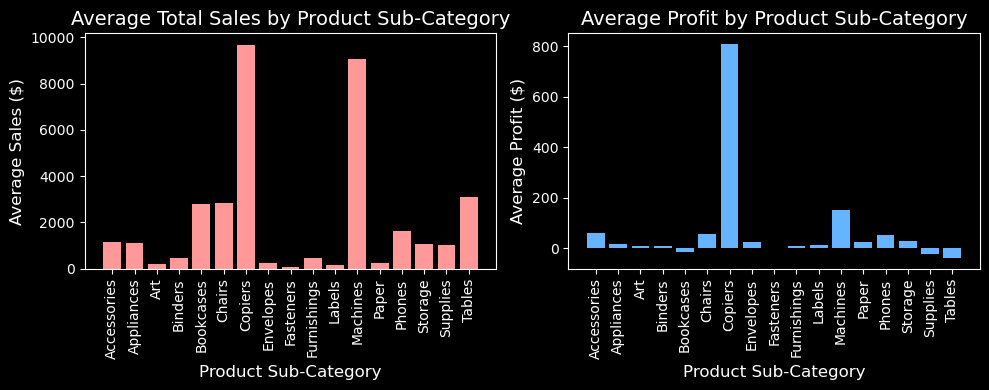

In [158]:
# Create a figure with subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Bar chart for Average Total Sales
axes[0].bar(AverageSales_Subcategory.index, AverageSales_Subcategory['Total Sales'], color='#ff9999')
axes[0].set_title('Average Total Sales by Product Sub-Category', fontsize=14)
axes[0].set_xlabel('Product Sub-Category', fontsize=12)
axes[0].set_ylabel('Average Sales ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Bar chart for Average Profit
axes[1].bar(AverageSales_Subcategory.index, AverageSales_Subcategory['Profit'], color='#66b3ff')
axes[1].set_title('Average Profit by Product Sub-Category', fontsize=14)
axes[1].set_xlabel('Product Sub-Category', fontsize=12)
axes[1].set_ylabel('Average Profit ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()


In [21]:
# Identify customer segment (Consumer, Corporate, Home Office) generates the most sales?
SegmentWise = df.groupby('Segment')[['Total Sales', 'Profit']].sum().round()
print(SegmentWise)

             Total Sales   Profit
Segment                          
Consumer       1358477.0  34271.0
Corporate       994148.0  26574.0
Home Office     721779.0  24956.0


Index(['index', 'Segment', 'Total Sales', 'Profit', 'Category'], dtype='object')


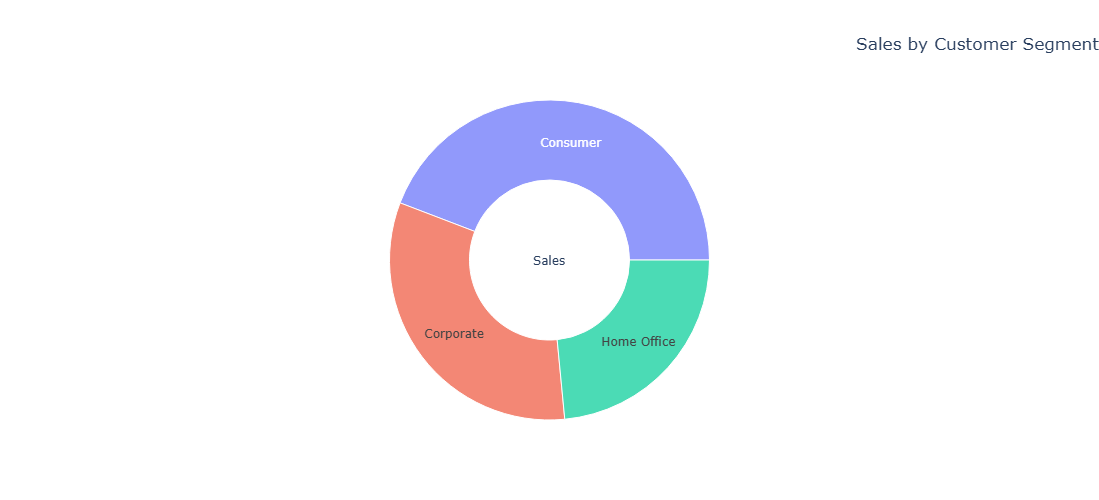

In [25]:
# Reset index to convert 'Segment' into a column and drop the unnecessary 'level_0' column if it exists
SegmentWise = SegmentWise.reset_index()

# Check the columns of the DataFrame
print(SegmentWise.columns)  # Ensure 'Segment' exists in the DataFrame

# Create a new column 'Category' to represent the hierarchical structure
SegmentWise['Category'] = 'Sales'  # This will be a constant value for each row

# Create the sunburst plot
fig = px.sunburst(
    SegmentWise,
    path=['Category', 'Segment'],  # Hierarchy: first "Category", then "Segment"
    values='Total Sales',  # The size of the segment is based on Total Sales
    hover_data=['Profit'],  # Display Profit when hovering
    title="Sales by Customer Segment"
)
# Update the layout for better display
fig.update_layout(
    width=600,  # Set the width of the plot
    height=500, # Set the height of the plot
    title={'x': 1.0}  # Optional: center the title
)
fig.show()

In [231]:
# Identify state generates the most sales?
StateWise = df.groupby('State')[['Total Sales', 'Profit']].sum().round()
StateWise.sort_values('Total Sales', ascending=False)
print(StateWise.head(10))

                      Total Sales   Profit
State                                     
Alabama                   11215.0    394.0
Arizona                   31100.0    317.0
Arkansas                  15598.0   1668.0
California               636730.0  22395.0
Colorado                  34708.0  -1192.0
Connecticut               16973.0   1150.0
Delaware                  19341.0   1523.0
District of Columbia        271.0     13.0
Florida                   83512.0   -684.0
Georgia                   37617.0   2300.0


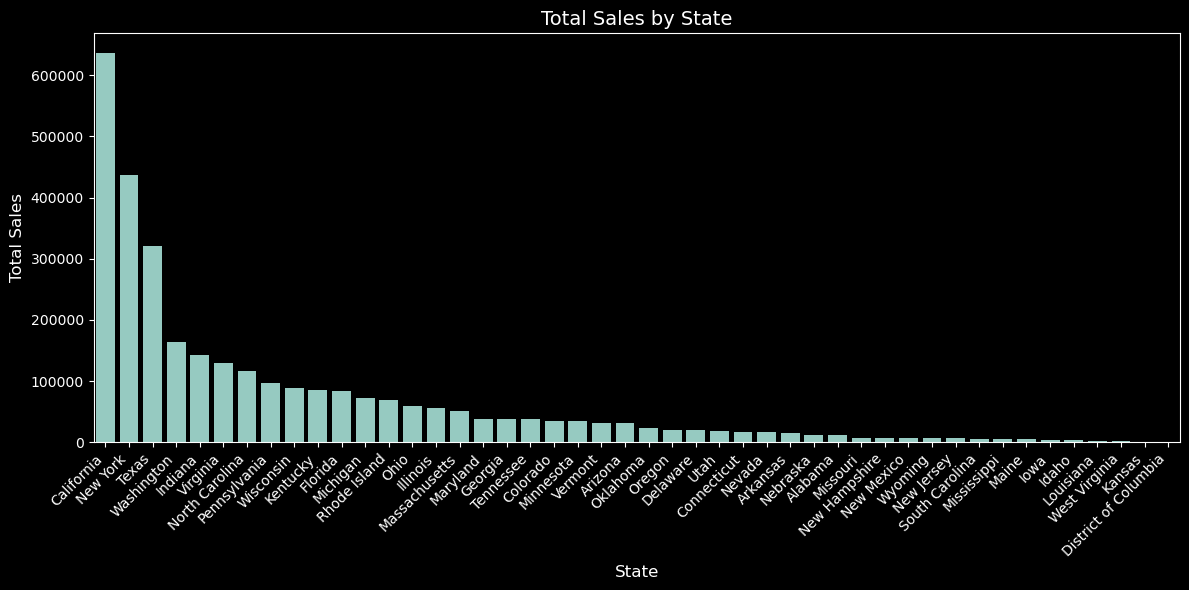

In [172]:
# Group by 'State' and calculate the sum of 'Total Sales' and 'Profit'
StateWise = df.groupby('State')[['Total Sales', 'Profit']].sum().round()

# Sort the 'StateWise' DataFrame by 'Total Sales' in descending order
StateWise_sorted = StateWise.sort_values('Total Sales', ascending=False)

# Create a bar plot for total sales by state
plt.figure(figsize=(12, 6))
sns.barplot(x=StateWise_sorted.index, y='Total Sales', data=StateWise_sorted)

# Adding labels and title
plt.title('Total Sales by State', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()


In [249]:
# Identify city generates the most sales?
CityWise = df.groupby('City')[['Total Sales', 'Profit']].sum().round()
CityWise.sort_values('Total Sales', ascending=False)
print(CityWise.head(10))

              Total Sales  Profit
City                             
Akron               214.0   -19.0
Albuquerque        1791.0   113.0
Alexandria        23937.0   188.0
Allen               551.0   -26.0
Amarillo           1970.0   -75.0
Anaheim           11210.0   272.0
Andover            2047.0   124.0
Ann Arbor          4445.0   229.0
Antioch              58.0     9.0
Apple Valley        181.0    24.0


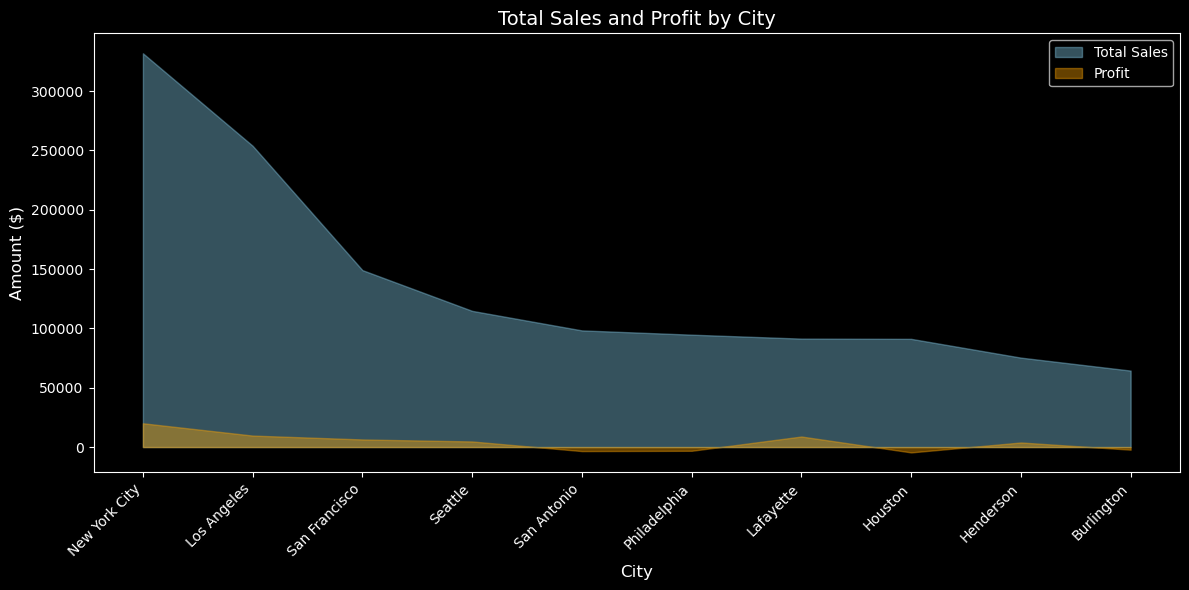

In [176]:
# Group by 'City' and calculate the sum of 'Total Sales' and 'Profit'
CityWise = df.groupby('City')[['Total Sales', 'Profit']].sum().round()

# Sort the 'CityWise' DataFrame by 'Total Sales' in descending order
CityWise_sorted = CityWise.sort_values('Total Sales', ascending=False)

# Select top cities for better visualization (optional, if too many cities)
CityWise_top = CityWise_sorted.head(10)

# Create an area plot
plt.figure(figsize=(12, 6))

# Plot area plot for Total Sales
plt.fill_between(CityWise_top.index, CityWise_top['Total Sales'], color="skyblue", alpha=0.4, label="Total Sales")
# Plot area plot for Profit
plt.fill_between(CityWise_top.index, CityWise_top['Profit'], color="orange", alpha=0.4, label="Profit")

# Adding labels and title
plt.title('Total Sales and Profit by City', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45, ha='right')

# Display the legend
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()


In [62]:
# Identify is the total sales & profit by each ship mode?
ShipModeWise = df.groupby('Ship Mode')[['Total Sales', 'Profit']].sum().round()
print(ShipModeWise)

                Total Sales   Profit
Ship Mode                           
First Class        538333.0  14234.0
Same Day           262970.0   6172.0
Second Class       653032.0  19647.0
Standard Class    1620069.0  45748.0


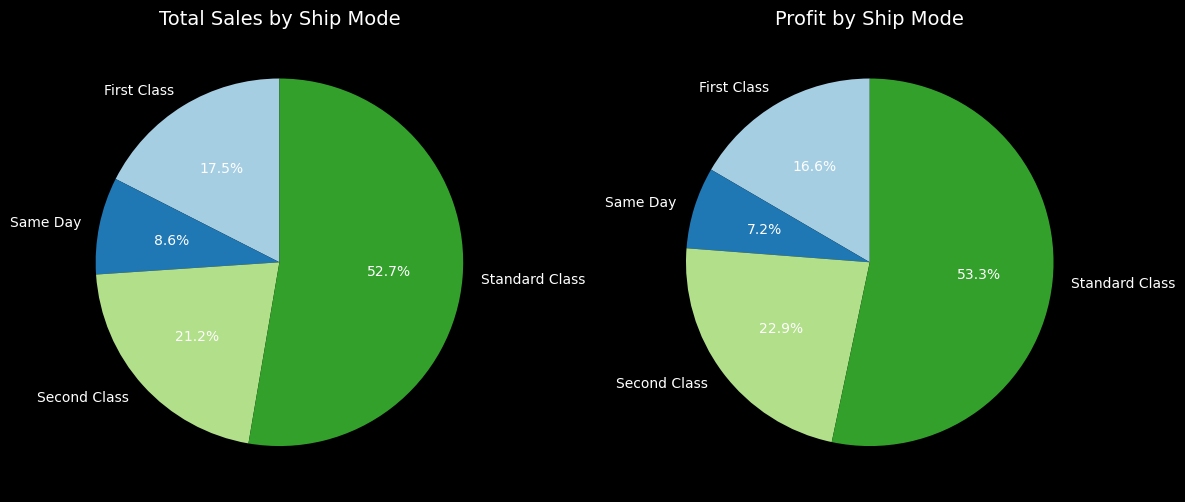

In [156]:
# Group by 'Ship Mode' and calculate the sum of 'Total Sales' and 'Profit'
ShipModeWise = df.groupby('Ship Mode')[['Total Sales', 'Profit']].sum().round()

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for Total Sales by Ship Mode
axes[0].pie(ShipModeWise['Total Sales'], labels=ShipModeWise.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[0].set_title('Total Sales by Ship Mode', fontsize=14)

# Pie chart for Profit by Ship Mode
axes[1].pie(ShipModeWise['Profit'], labels=ShipModeWise.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[1].set_title('Profit by Ship Mode', fontsize=14)

# Display the pie charts
plt.tight_layout()  # Ensures the pie charts don't overlap
plt.show()

In [257]:
# Identify the total sales & profit by each product?
ProductWiseSales = df.groupby('Product Name')['Total Sales'].sum().round().sort_values(ascending=False).head(5)
print(ProductWiseSales)

Product Name
Canon imageCLASS 2200 Advanced Copier                                 87500.0
Lexmark MX611dhe Monochrome Laser Printer                             71399.0
Hewlett Packard LaserJet 3310 Copier                                  59518.0
Honeywell Enviracaire Portable HEPA Air Cleaner for 17' x 22' Room    44196.0
HP Designjet T520 Inkjet Large Format Printer - 24" Color             43750.0
Name: Total Sales, dtype: float64


In [253]:
ProductWiseProfit = df.groupby('Product Name')['Profit'].sum().round().sort_values(ascending=False).head(5)
print(ProductWiseProfit)

Product Name
Canon imageCLASS 2200 Advanced Copier                                 8400.0
Hewlett Packard LaserJet 3310 Copier                                  3168.0
HP Designjet T520 Inkjet Large Format Printer - 24" Color             2800.0
Ativa V4110MDD Micro-Cut Shredder                                     2401.0
Honeywell Enviracaire Portable HEPA Air Cleaner for 17' x 22' Room    2282.0
Name: Profit, dtype: float64


In [68]:
# What is the total sales & profit by each region?
RegionWise = df.groupby('Region')[['Total Sales', 'Profit']].sum().round()
print(RegionWise)

         Total Sales   Profit
Region                       
Central     762800.0  13350.0
East        840971.0  32964.0
South       531325.0  10400.0
West        939308.0  29087.0


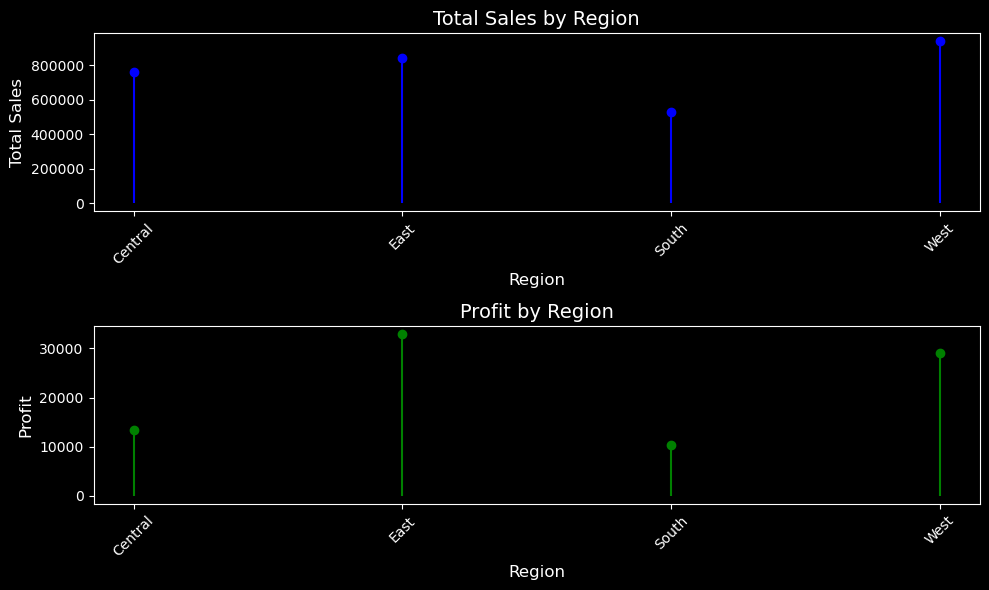

In [154]:
# Group by 'Region' and calculate the sum of 'Total Sales' and 'Profit'
RegionWise = df.groupby('Region')[['Total Sales', 'Profit']].sum().round()

# Data for plotting
regions = RegionWise.index
total_sales = RegionWise['Total Sales']
profit = RegionWise['Profit']

# Create a figure
plt.figure(figsize=(10, 6))

# Create a stem plot for Total Sales
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first plot
plt.stem(regions, total_sales, basefmt=" ", linefmt='b-', markerfmt='bo', label='Total Sales')
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)

# Create a stem plot for Profit
plt.subplot(2, 1, 2)  # 2 rows, 1 column, second plot
plt.stem(regions, profit, basefmt=" ", linefmt='g-', markerfmt='go', label='Profit')
plt.title('Profit by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.xticks(rotation=45)


# Display the plots
plt.tight_layout()
plt.show()


## Time-based Analysis ##

In [73]:
# Identify the total sales and profit over time year?
# Convert 'Order Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month from 'Order Date'
df['Year'] = df['Order Date'].dt.year

# Group by Year and Month and calculate total sales and profit
SalesProfit_by_Year = df.groupby('Year')[['Total Sales', 'Profit']].sum().round()

# Print the result
print(SalesProfit_by_Year)

      Total Sales   Profit
Year                      
2014     544583.0  13820.0
2015     583515.0  12556.0
2016     980794.0  36505.0
2017     965512.0  22921.0


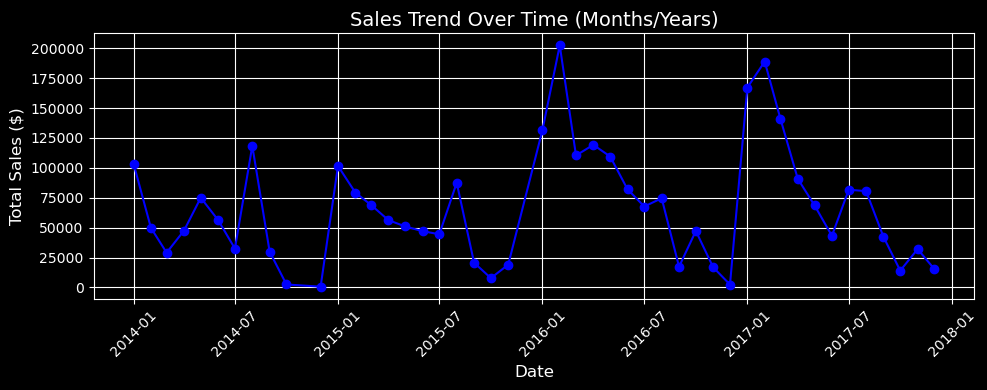

In [265]:
# How does the sales trend look over the months/years?
# Convert 'Order Date' to datetime format if it's not already
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the 'Year' and 'Month' from 'Order Date'
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Group by Year and Month to calculate total sales for each period
sales_trend = df.groupby(['Year', 'Month'])['Total Sales'].sum().reset_index()

# Create a 'Date' column for easier plotting
sales_trend['Date'] = pd.to_datetime(sales_trend['Year'].astype(str) + '-' + sales_trend['Month'].astype(str) + '-01')

# Plotting the sales trend over months/years
plt.figure(figsize=(10, 4))
plt.plot(sales_trend['Date'], sales_trend['Total Sales'], marker='o', color='b', label='Total Sales')

# Adding titles and labels
plt.title('Sales Trend Over Time (Months/Years)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

In [77]:
# Make a copy of the filtered DataFrame
year = df[df['Order Date'].dt.year.isin([2014])].copy()
# Add the 'Month' column
year['Month'] = year['Order Date'].dt.month
# Group by month and calculate sum of 'Total Sales' and 'Profit'
SalesProfit_by_Month = year.groupby('Month')[['Total Sales', 'Profit']].sum().round()
print(SalesProfit_by_Month)

       Total Sales  Profit
Month                     
1         103464.0  3366.0
2          49761.0  2499.0
3          29024.0  -490.0
4          47464.0  3631.0
5          74988.0  1673.0
6          56283.0  1989.0
7          32429.0   955.0
8         118316.0  -602.0
9          29809.0  1081.0
10          2427.0    49.0
12           618.0  -332.0


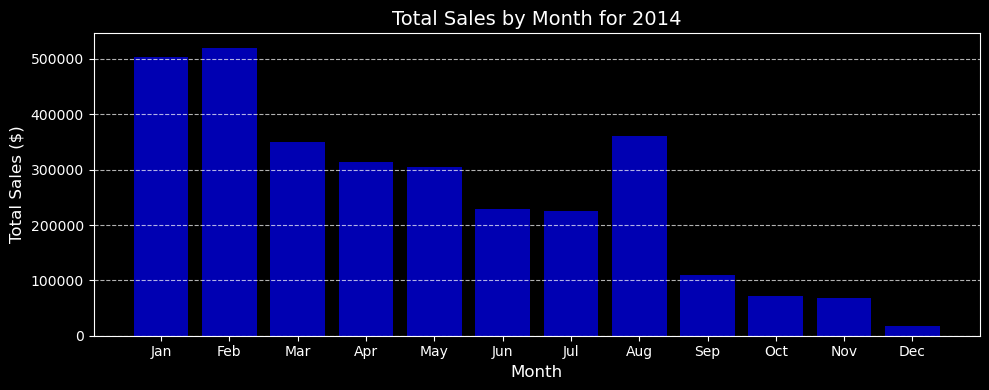

In [150]:
# Identify months have the highest sales?
# Convert 'Order Date' to datetime format if it's not already
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the 'Month' from 'Order Date'
df['Month'] = df['Order Date'].dt.month

# Group by Month to calculate total sales for each month
monthly_sales = df.groupby('Month')['Total Sales'].sum().reset_index()

# Plotting the total sales by month
plt.figure(figsize=(10, 4))
plt.bar(monthly_sales['Month'], monthly_sales['Total Sales'], color='b', alpha=0.7)

# Adding titles and labels
plt.title('Total Sales by Month for 2014', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(monthly_sales['Month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [81]:
# Make a copy of the filtered DataFrame
year = df[df['Order Date'].dt.year.isin([2015])].copy()
# Add the 'Month' column
year['Month'] = year['Order Date'].dt.month
# Group by month and calculate sum of 'Total Sales' and 'Profit'
SalesProfit_by_Month = year.groupby('Month')[['Total Sales', 'Profit']].sum().round()
print(SalesProfit_by_Month)

       Total Sales  Profit
Month                     
1         101576.0  3004.0
2          79289.0     1.0
3          68945.0   672.0
4          56277.0  1543.0
5          50955.0  -158.0
6          47035.0  1810.0
7          44441.0  -947.0
8          87560.0  4888.0
9          20676.0  1117.0
10          7745.0   190.0
11         19017.0   435.0


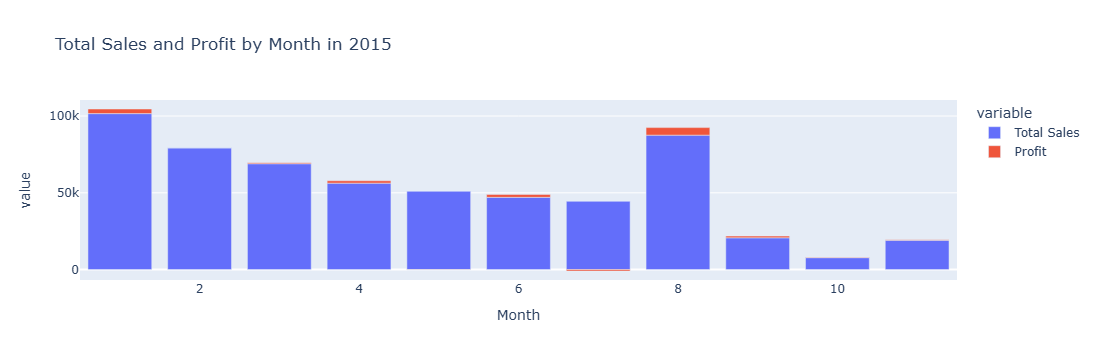

In [148]:
import plotly.express as px

# Make a copy of the filtered DataFrame
year = df[df['Order Date'].dt.year.isin([2015])].copy()

# Add the 'Month' column
year['Month'] = year['Order Date'].dt.month

# Group by month and calculate sum of 'Total Sales' and 'Profit'
SalesProfit_by_Month = year.groupby('Month')[['Total Sales', 'Profit']].sum().round()

# Create an interactive bar plot with Plotly
fig = px.bar(SalesProfit_by_Month, 
             x=SalesProfit_by_Month.index,  # 'Month' column as x-axis
             y=['Total Sales', 'Profit'],  # Columns for y-axis
             labels={'Total Sales': 'Total Sales ($)', 'Profit': 'Profit ($)'},
             title="Total Sales and Profit by Month in 2015")

# Show the plot
fig.show()


In [84]:
# Make a copy of the filtered DataFrame
year = df[df['Order Date'].dt.year.isin([2016])].copy()
# Add the 'Month' column
year['Month'] = year['Order Date'].dt.month
# Group by month and calculate sum of 'Total Sales' and 'Profit'
SalesProfit_by_Month = year.groupby('Month')[['Total Sales', 'Profit']].sum().round()
print(SalesProfit_by_Month)

       Total Sales   Profit
Month                      
1         131379.0   7057.0
2         202388.0  13891.0
3         110356.0   1519.0
4         119224.0   5032.0
5         109464.0   3226.0
6          82092.0   1384.0
7          67622.0   3616.0
8          74627.0   -248.0
9          17303.0    428.0
10         47204.0    505.0
11         16769.0     28.0
12          2365.0     66.0


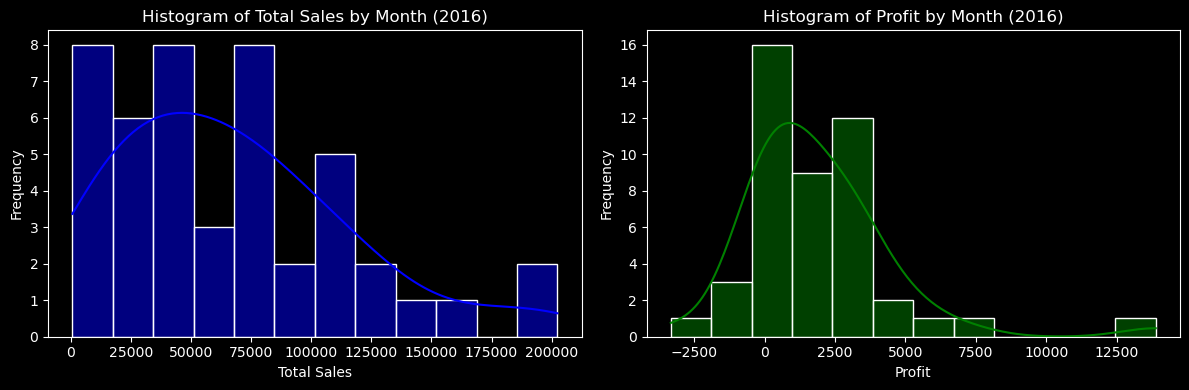

In [144]:
# Plotting histograms for 'Total Sales' and 'Profit'
plt.figure(figsize=(12, 4))

# Histogram for 'Total Sales'
plt.subplot(1, 2, 1)
sns.histplot(SalesProfit_by_Month['Total Sales'], bins=12, kde=True, color='blue')
plt.title('Histogram of Total Sales by Month (2016)')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')

# Histogram for 'Profit'
plt.subplot(1, 2, 2)
sns.histplot(SalesProfit_by_Month['Profit'], bins=12, kde=True, color='green')
plt.title('Histogram of Profit by Month (2016)')
plt.xlabel('Profit')
plt.ylabel('Frequency')

# Display the plots
plt.tight_layout()
plt.show()

In [86]:
# Make a copy of the filtered DataFrame
year = df[df['Order Date'].dt.year.isin([2017])].copy()
# Add the 'Month' column
year['Month'] = year['Order Date'].dt.month
# Group by month and calculate sum of 'Total Sales' and 'Profit'
SalesProfit_by_Month = year.groupby('Month')[['Total Sales', 'Profit']].sum().round()
print(SalesProfit_by_Month)

       Total Sales  Profit
Month                     
1         167176.0  3579.0
2         188890.0  3050.0
3         141064.0  5389.0
4          90845.0 -3332.0
5          68558.0  2757.0
6          43143.0  1562.0
7          81690.0  3093.0
8          80509.0  2939.0
9          42306.0  2483.0
10         14014.0   100.0
11         32024.0   953.0
12         15294.0   348.0


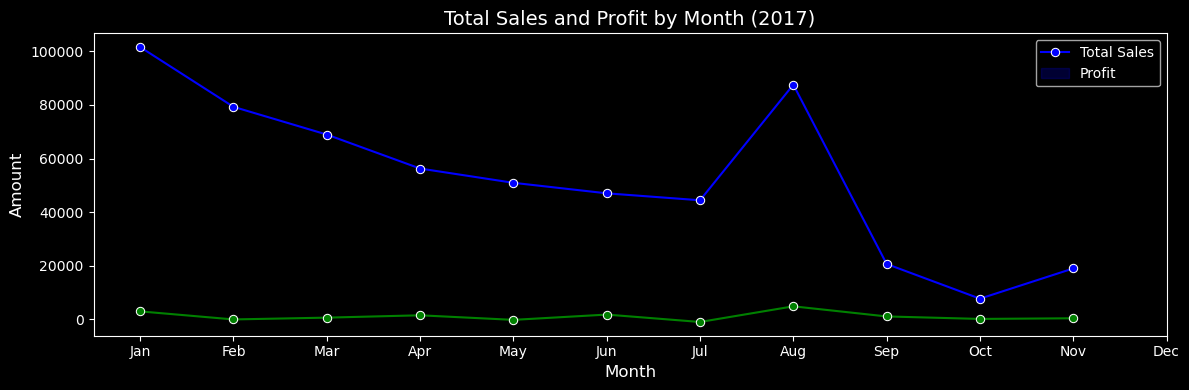

In [178]:
# Plotting line plot for 'Total Sales' and 'Profit'
plt.figure(figsize=(12, 4))

# Line plot for 'Total Sales'
sns.lineplot(data=SalesProfit_by_Month, x=SalesProfit_by_Month.index, y='Total Sales', marker='o', color='blue')

# Line plot for 'Profit'
sns.lineplot(data=SalesProfit_by_Month, x=SalesProfit_by_Month.index, y='Profit', marker='o', color='green')

# Adding labels and title
plt.title('Total Sales and Profit by Month (2017)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount', fontsize=12)

# Setting x-axis labels for months
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Display the legend manually by specifying labels
plt.legend(labels=['Total Sales', 'Profit'])

# Show the plot
plt.tight_layout()
plt.show()


In [134]:
# Filter the data for specific years (2014, 2015, 2016, 2017)
year = df[df['Order Date'].dt.year.isin([2014, 2015, 2016, 2017])]

# Extract Month and Year from 'Order Date'
year['Month'] = year['Order Date'].dt.month
year['Year'] = year['Order Date'].dt.year

# Group by Year and Month and calculate total sales and profit
SalesProfit_by_Month = year.groupby(['Year', 'Month'])[['Total Sales', 'Profit']].sum().round()

# Print the result
print(SalesProfit_by_Month)

            Total Sales   Profit
Year Month                      
2014 1         103464.0   3366.0
     2          49761.0   2499.0
     3          29024.0   -490.0
     4          47464.0   3631.0
     5          74988.0   1673.0
     6          56283.0   1989.0
     7          32429.0    955.0
     8         118316.0   -602.0
     9          29809.0   1081.0
     10          2427.0     49.0
     12           618.0   -332.0
2015 1         101576.0   3004.0
     2          79289.0      1.0
     3          68945.0    672.0
     4          56277.0   1543.0
     5          50955.0   -158.0
     6          47035.0   1810.0
     7          44441.0   -947.0
     8          87560.0   4888.0
     9          20676.0   1117.0
     10          7745.0    190.0
     11         19017.0    435.0
2016 1         131379.0   7057.0
     2         202388.0  13891.0
     3         110356.0   1519.0
     4         119224.0   5032.0
     5         109464.0   3226.0
     6          82092.0   1384.0
     7    

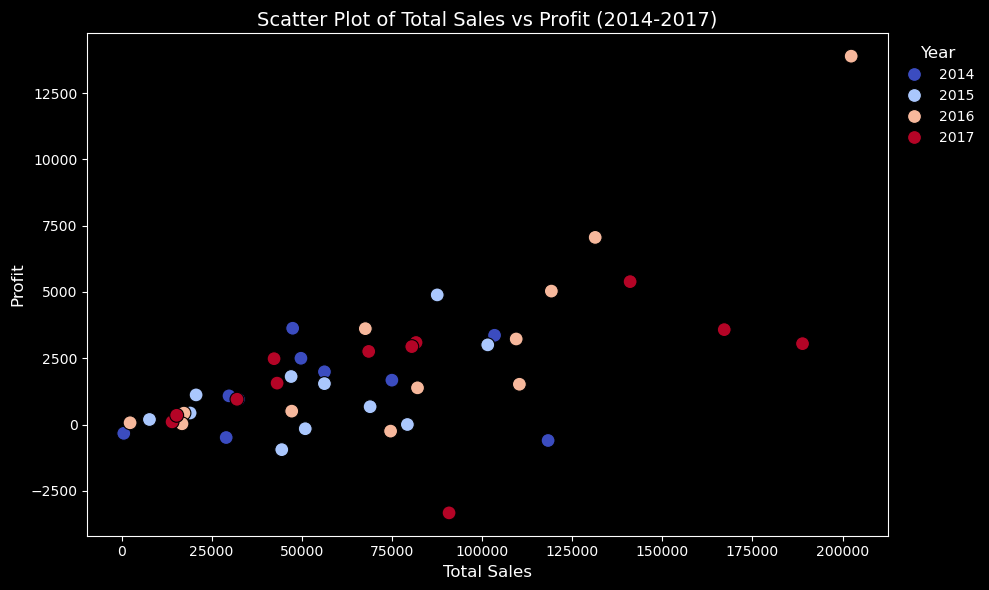

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the data for specific years (2014, 2015, 2016, 2017)
year = df[df['Order Date'].dt.year.isin([2014, 2015, 2016, 2017])]

# Extract Month and Year from 'Order Date'
year['Month'] = year['Order Date'].dt.month
year['Year'] = year['Order Date'].dt.year

# Group by Year and Month and calculate total sales and profit
SalesProfit_by_Month = year.groupby(['Year', 'Month'])[['Total Sales', 'Profit']].sum().round()

# Reset index to avoid conflicts with index columns
SalesProfit_by_Month = SalesProfit_by_Month.reset_index()

# Set dark background style
plt.style.use('dark_background')

# Create a scatter plot for 'Total Sales' vs 'Profit' with Year as hue
plt.figure(figsize=(10, 6))

# Scatter plot using Seaborn with 'Year' as the hue
sns.scatterplot(data=SalesProfit_by_Month, x='Total Sales', y='Profit', hue='Year', palette='coolwarm', s=100, edgecolor='black')

# Adding labels and title
plt.title('Scatter Plot of Total Sales vs Profit (2014-2017)', fontsize=14, color='white')
plt.xlabel('Total Sales', fontsize=12, color='white')
plt.ylabel('Profit', fontsize=12, color='white')

# Display the plot
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1, 1), title_fontsize='12', fontsize='10', frameon=False)
plt.tight_layout()
plt.show()


## Customer Analysis ##

In [276]:
# Identify the total sales and profit by customer (Customer ID or Customer Name)?
# Group by Customer ID to calculate total sales and profit
customer_sales_profit = df.groupby(['Customer ID','Customer Name'])[['Total Sales', 'Profit']].sum().reset_index()

# Sorting by Total Sales and Profit to see top customers
customer_sales_profit_sorted_sales = customer_sales_profit.sort_values(by='Total Sales', ascending=False)
customer_sales_profit_sorted_profit = customer_sales_profit.sort_values(by='Profit', ascending=False)
print(customer_sales_profit_sorted_sales)
print(customer_sales_profit_sorted_profit)

    Customer ID     Customer Name  Total Sales     Profit
623    TC-20980      Tamara Chand    89645.374  8745.0635
75     BM-11140      Becky Martin    85675.036 -1759.8593
419    ME-17320     Maria Etezadi    57569.132  1754.3099
197    DR-12940     Daniel Raglin    56401.910  3050.3344
359    KF-16285    Karen Ferguson    51899.202   748.8844
..          ...               ...          ...        ...
50     AW-10930   Arthur Wiediger        9.656     1.7248
30     AI-10855    Arianne Irving        6.680     3.2064
526    RB-19705      Roger Barcio        4.982    -3.7880
472    NF-18475  Neil Französisch        4.710     0.0000
641    TS-21340     Toby Swindell        1.424    -1.8904

[669 rows x 4 columns]
    Customer ID     Customer Name  Total Sales     Profit
623    TC-20980      Tamara Chand    89645.374  8745.0635
197    DR-12940     Daniel Raglin    56401.910  3050.3344
574    SE-20110      Sanjit Engle    44171.780  2825.2862
356    KD-16495     Keith Dawkins    22288.578  

In [269]:
# Identify customers have made the highest number of orders?
# Group by Customer ID and count the number of unique Order IDs for each customer
customer_order_count = df.groupby(['Customer Name', 'Customer ID'])['Order ID'].nunique().reset_index()

# Rename the column to "Number of Orders"
customer_order_count = customer_order_count.rename(columns={'Order ID': 'Number of Orders'})

# Sort by Number of Orders in descending order
Top5Customerby_OrderCount = customer_order_count.sort_values(by='Number of Orders', ascending=False)
print(Top5Customerby_OrderCount.head(10))

           Customer Name Customer ID  Number of Orders
581       Shahid Hopkins    SH-20395                 7
484         Noel Staavos    NS-18640                 7
561           Sam Zeldin    SZ-20035                 6
120         Chris Cortes    CC-12220                 6
545       Roland Schwarz    RS-19765                 5
257          George Bell    GB-14530                 5
412  Maribeth Schnelling    MS-17365                 5
356    Katherine Nockton    KN-16390                 5
536             Rob Dowd    RD-19585                 5
425         Matt Collins    MC-17575                 5


In [95]:
# Group by City and State to calculate total sales
city_state_sales = df.groupby(['City', 'State'])['Total Sales'].sum().reset_index()

# Sort by Total Sales in descending order to identify the highest sales locations
city_state_sales_sorted = city_state_sales.sort_values(by='Total Sales', ascending=False).round()
print(city_state_sales_sorted.head(10))

              City         State  Total Sales
234  New York City      New York     331850.0
192    Los Angeles    California     253904.0
309  San Francisco    California     149115.0
317        Seattle    Washington     114783.0
307    San Antonio         Texas      98314.0
263   Philadelphia  Pennsylvania      94712.0
148        Houston         Texas      91197.0
168      Lafayette       Indiana      89345.0
140      Henderson      Kentucky      65246.0
272     Providence  Rhode Island      64073.0


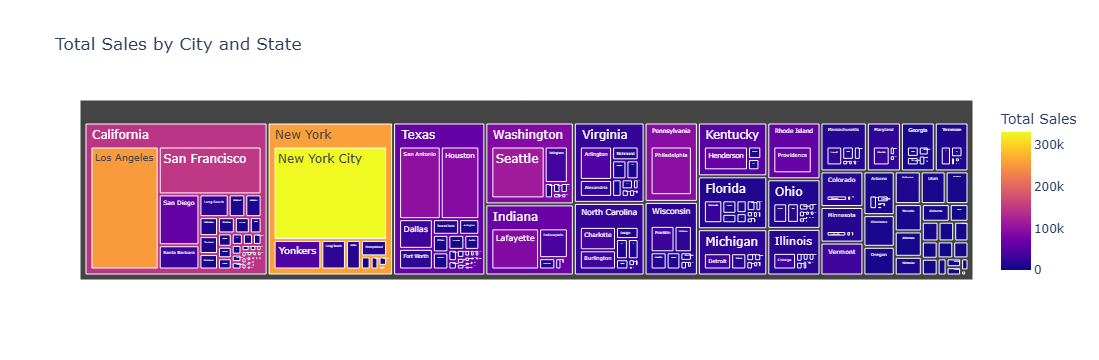

In [138]:
# DataFrame = 'df' and it contains the relevant columns ('City', 'State', 'Total Sales')
# Group by City and State to calculate total sales
city_state_sales = df.groupby(['City', 'State'])['Total Sales'].sum().reset_index()
# Sort by Total Sales in descending order
city_state_sales_sorted = city_state_sales.sort_values(by='Total Sales', ascending=False).round()

# Create a treemap
fig = px.treemap(city_state_sales_sorted, 
                 path=['State', 'City'],  # Hierarchy: State -> City
                 values='Total Sales',  # Values used for the size of the rectangles
                 color='Total Sales',  # Color based on Total Sales
                 hover_data=['Total Sales'],  # Display Total Sales on hover
                 title="Total Sales by City and State")
fig.show()

In [98]:
# How many products in each sub-category are sold in total (Quantity)?
# Group by Sub-Category and calculate the total Quantity sold
sub_category_quantity = df.groupby('Sub-Category')['Quantity'].sum().reset_index()

# Sort by Quantity sold in descending order
sub_category_quantity_sorted = sub_category_quantity.sort_values(by='Quantity', ascending=False)

# Print the sub-categories and their total quantities sold
print(sub_category_quantity_sorted)

   Sub-Category  Quantity
3       Binders      1716
12        Paper      1392
9   Furnishings       975
14      Storage       863
0   Accessories       834
13       Phones       817
2           Art       801
5        Chairs       634
1    Appliances       468
10       Labels       404
16       Tables       338
8     Fasteners       233
7     Envelopes       225
4     Bookcases       225
15     Supplies       167
11     Machines       152
6       Copiers        76


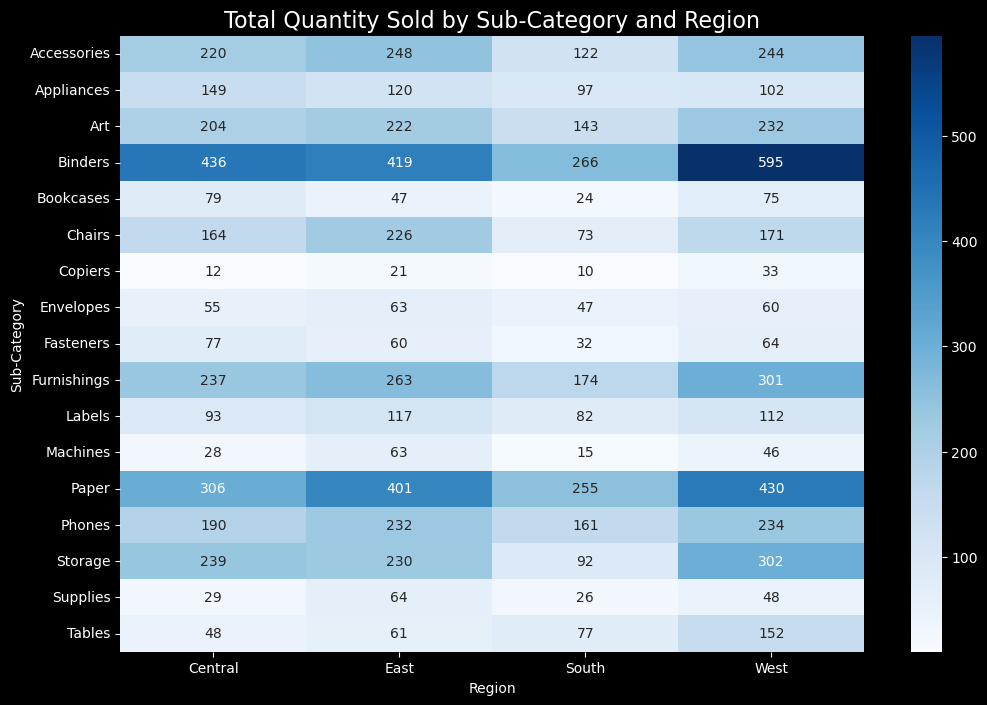

In [99]:
# 'Quantity' data across different 'Sub-Categories' and 'Regions'
heatmap_data = df.pivot_table(values='Quantity', index='Sub-Category', columns='Region', aggfunc='sum')

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Blues', fmt='d')
plt.title('Total Quantity Sold by Sub-Category and Region', fontsize=16)
plt.show()


In [193]:
df.groupby(['Category', 'Sub-Category'])['Order ID'].nunique().reset_index()

,Category,Sub-Category,Order ID
0,Furniture,Bookcases,56
1,Furniture,Chairs,159
2,Furniture,Furnishings,238
3,Furniture,Tables,89
4,Office Supplies,Appliances,120
5,Office Supplies,Art,196
6,Office Supplies,Binders,356
7,Office Supplies,Envelopes,64
8,Office Supplies,Fasteners,57
9,Office Supplies,Labels,104


### Visualizations to Support Insights:

Trend Analysis: Line chart, Histogram for sales and profit over time (yearly and monthly trends).
Heat map for Total Quantity Sold by Sub-Category and Region
Tree Map used for Total Sales by City and State.
Scatter Plot of Total Sales vs Profit from 2014-2017.
Stem Plot for total sales & profit by each region
Area chart used for sum of 'Total Sales' and 'Profit' by city.
Sunburst plot or donut chart used for customer segment (Consumer, Corporate, Home Office).
Bar chart for Average Total Sales & Profit.
Pie chart used for Total Sales and Profit by Ship mode & product category generates the most sales and profit.


### Conclusion: #

Sales and Profit Performance:
Total sales reached $3,074,404 & profit $85801.0 but the profit margin is relatively low at 2.8%.
Technology is the most profitable category, despite Furniture driving the highest sales.
Sub-category insights show Copiers as the top-performing sub-category in terms of both sales and profit, while Fasteners significantly underperform.

Customer Insights:
Consumers contribute the largest share of sales and profit, followed by the Corporate and Home Office segments.
Key customers like Tamara Chand drive substantial sales and profit, emphasizing the importance of customer retention.
Negative profitability for certain customers highlights areas where pricing or discount strategies may need adjustment.

Regional Insights:
California leads in sales and profit, while New York City stands out as the most profitable city.
The West region dominates in total sales, while the East region achieves the highest profitability.
There are opportunities to grow sales in underperforming regions.

Product and Shipping Mode Analysis:
High-performing products, such as the Canon imageCLASS Copier, drive significant sales and profit, whereas low-performing products and sub-categories need optimization or repositioning.
The Standard Class shipping mode generates the highest sales and profit, but diversifying and promoting alternative shipping methods could increase customer satisfaction.

Temporal Trends:
Sales peaked in 2016, followed by a slight decline in 2017, which requires further investigation.
Monthly trends indicate January 2015 as a high-sales period, suggesting potential for seasonal campaigns.